# 02. EDA (FuxiCTR parquet 산출물 기반)

`01_Build_dataset.ipynb`의 산출물(`data/<dataset_id>/{train,valid,test}.parquet` + `feature_map.json`)만 로드해 EDA를 수행한다.
`DATASET` 스위치만 바꾸면 모든 데이터셋에 같은 EDA를 적용할 수 있다.

설계:
- 기본 통계 / 레이블 분포
- 카테고리 피쳘: Top-K 빈도 및 카테고리별 CTR
- Numeric 피쳘: 히스토그램 + 라벨 관계
- Sequence 피쳘: 길이 분포, 토큰 빈도, 바이그램 전이 확률, 길이별 CTR

FuxiCTR parquet의 카테고리/시퀀스 값은 토큰 인덱스(int)로 저장되어 있으며 `feature_vocab.json`으로 원본 문자열 역조회 가능하다.

In [1]:
import sys, json
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_HERE = Path.cwd()
if str(_HERE) not in sys.path:
    sys.path.insert(0, str(_HERE))
from utils import nb_utils as U

# 01에서 만든 dataset_id를 그대로 사용
DATASET_ID = 'TAAC2026'   # 필요시 변경: KuaiVideo_x1, MicroVideo1.7M_x1, TAAC2026
SPLIT      = 'train'                   # 'train' | 'valid' | 'test'
TOPK       = 20
SAMPLE_N   = 200_000                   # 큰 데이터셋 방어용 샘플 상한(None이면 전체)
print('dataset =', DATASET_ID, ' split =', SPLIT)

dataset = TAAC2026  split = train


## 1. 로드

In [2]:
ds_dir = U.DATA_ROOT / DATASET_ID
fmap   = U.load_feature_map(DATASET_ID)
LABELS = fmap['labels']

def _feature_specs(fmap):
    out = {}
    for entry in fmap['features']:
        for name, spec in entry.items():
            out[name] = spec
    return out
FEATURES = _feature_specs(fmap)

CAT_COLS = [n for n, s in FEATURES.items() if s['type'] == 'categorical']
NUM_COLS = [n for n, s in FEATURES.items() if s['type'] == 'numeric']
SEQ_COLS = [n for n, s in FEATURES.items() if s['type'] == 'sequence']
print(f'categorical({len(CAT_COLS)}): {CAT_COLS[:8]}{"..." if len(CAT_COLS)>8 else ""}')
print(f'numeric({len(NUM_COLS)}):     {NUM_COLS}')
print(f'sequence({len(SEQ_COLS)}):    {SEQ_COLS}')
print(f'labels:                 {LABELS}')

# parquet 로드: 단일파일({split}.parquet) 또는 디렉토리({split}/*.parquet) 모두 지원
single = ds_dir / f'{SPLIT}.parquet'
folder = ds_dir / SPLIT
if single.exists():
    df = pd.read_parquet(single)
elif folder.is_dir():
    df = pd.concat([pd.read_parquet(p) for p in sorted(folder.rglob('*.parquet'))], ignore_index=True)
else:
    raise FileNotFoundError(f'{single} / {folder} neither exists. 01_Build_dataset 도는 수행 필요.')
print(f'loaded shape = {df.shape}')
if SAMPLE_N and len(df) > SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=0).reset_index(drop=True)
    print(f'sampled down to {len(df):,} rows')

categorical(52): ['user_id', 'item_id', 'user_int_feats_1', 'user_int_feats_3', 'user_int_feats_4', 'user_int_feats_48', 'user_int_feats_49', 'user_int_feats_50']...
numeric(1):     ['timestamp']
sequence(49):    ['user_int_feats_15', 'user_int_feats_60', 'user_int_feats_80', 'item_int_feats_11', 'domain_a_seq_38', 'domain_a_seq_39', 'domain_a_seq_40', 'domain_a_seq_41', 'domain_a_seq_42', 'domain_a_seq_43', 'domain_a_seq_44', 'domain_a_seq_45', 'domain_a_seq_46', 'domain_b_seq_67', 'domain_b_seq_68', 'domain_b_seq_69', 'domain_b_seq_70', 'domain_b_seq_71', 'domain_b_seq_72', 'domain_b_seq_73', 'domain_b_seq_74', 'domain_b_seq_75', 'domain_b_seq_76', 'domain_b_seq_77', 'domain_b_seq_78', 'domain_b_seq_79', 'domain_b_seq_88', 'domain_c_seq_27', 'domain_c_seq_28', 'domain_c_seq_29', 'domain_c_seq_30', 'domain_c_seq_31', 'domain_c_seq_32', 'domain_c_seq_33', 'domain_c_seq_34', 'domain_c_seq_35', 'domain_c_seq_36', 'domain_c_seq_37', 'domain_c_seq_47', 'domain_d_seq_17', 'domain_d_seq_18',

## 2. 기본 통계

In [3]:
print(f'records      = {len(df):,}')
for lbl in LABELS:
    print(f'label[{lbl}]  mean={df[lbl].mean():.4f}  sum={int(df[lbl].sum()):,}')
print('\nnull rate per column (top 15):')
null_rate = df.isna().mean().sort_values(ascending=False).head(15)
print(null_rate.to_string())

print('\nvocab_size per categorical feature (from feature_map):')
print(pd.Series({c: FEATURES[c]['vocab_size'] for c in CAT_COLS}).sort_values(ascending=False).head(15).to_string())

records      = 630
label[label]  mean=0.1222  sum=77

null rate per column (top 15):
label              0.0
fid_87             0.0
fid_61             0.0
domain_d_seq_26    0.0
domain_d_seq_25    0.0
domain_d_seq_24    0.0
domain_d_seq_23    0.0
domain_d_seq_22    0.0
domain_d_seq_21    0.0
domain_d_seq_20    0.0
domain_d_seq_19    0.0
domain_d_seq_18    0.0
domain_d_seq_17    0.0
domain_c_seq_47    0.0
domain_c_seq_37    0.0

vocab_size per categorical feature (from feature_map):
user_id              632
item_id              542
item_int_feats_16    454
user_int_feats_56    327
user_int_feats_54    322
item_int_feats_12    278
item_int_feats_7     272
user_int_feats_3     271
user_int_feats_4     226
user_int_feats_53    221
item_int_feats_6     178
item_int_feats_8     166
user_int_feats_57    100
item_int_feats_10     97
item_int_feats_85     71


## 3. 카테고리 피쳘 EDA
파켔 변환된 카테고리 값은 토큰 ID(int). Top-K ID별 빈도와 한 라벨에 대한 CTR을 함께 표시.

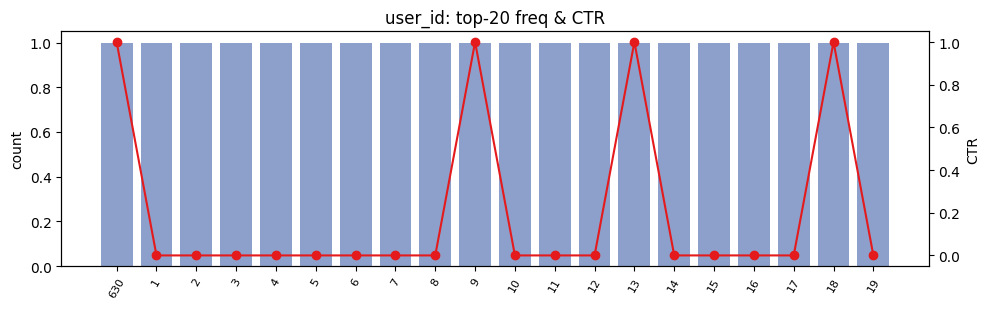

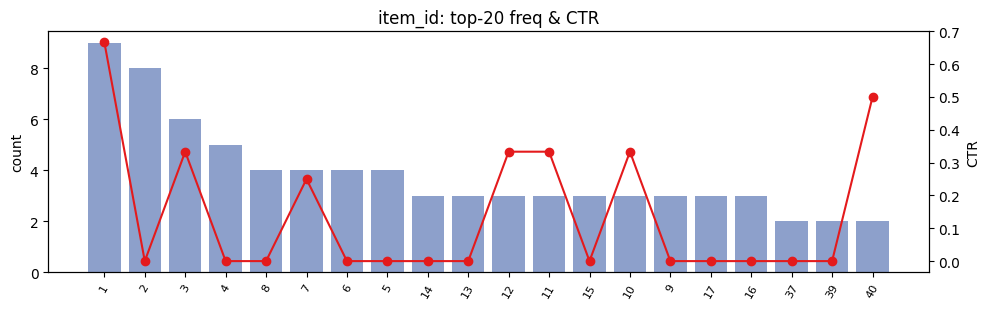

In [4]:
def plot_cat_freq(df, col, label_col, topk=20):
    g = df.groupby(col)[label_col].agg(['count', 'mean']).rename(columns={'count':'n', 'mean':'ctr'})
    g = g.sort_values('n', ascending=False).head(topk)
    fig, ax1 = plt.subplots(figsize=(10, 3.2))
    ax1.bar(range(len(g)), g['n'], color='#8da0cb')
    ax1.set_xticks(range(len(g))); ax1.set_xticklabels(g.index.astype(str), rotation=60, fontsize=8)
    ax1.set_ylabel('count'); ax1.set_title(f'{col}: top-{topk} freq & CTR')
    ax2 = ax1.twinx(); ax2.plot(range(len(g)), g['ctr'], 'o-', color='#e41a1c'); ax2.set_ylabel('CTR')
    plt.tight_layout(); plt.show()

# 모든 카테고리를 그리면 너무 많아 지식명 상위 6개만 (근본 식별자가 많이 들어있는 그룹)
pick = [c for c in ('user_id','item_id','cate_id','adgroup_id','campaign_id','brand') if c in CAT_COLS]
if not pick:
    pick = CAT_COLS[:6]
lbl = LABELS[0]
for c in pick:
    plot_cat_freq(df, c, lbl, topk=TOPK)

## 4. Numeric 피쳘 EDA

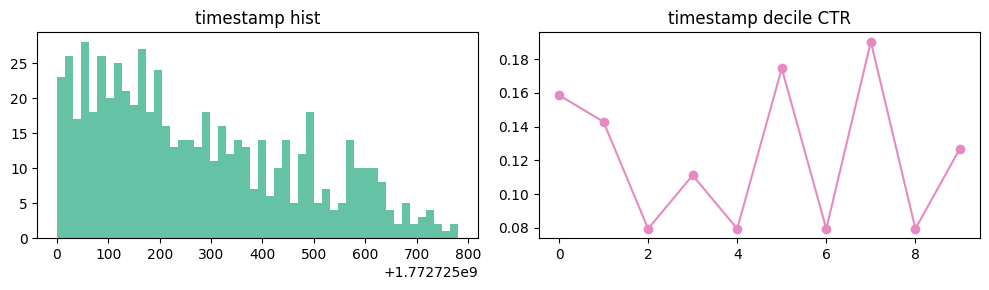

In [5]:
if NUM_COLS:
    for c in NUM_COLS:
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        axes[0].hist(df[c].dropna(), bins=50, color='#66c2a5'); axes[0].set_title(f'{c} hist')
        # label별 분포 (bin 단위 CTR)
        bins = pd.qcut(df[c].rank(method='first'), q=10, labels=False)
        ctr = df.assign(_b=bins).groupby('_b')[lbl].mean()
        axes[1].plot(ctr.index, ctr.values, 'o-', color='#e78ac3'); axes[1].set_title(f'{c} decile CTR')
        plt.tight_layout(); plt.show()
else:
    print('no numeric features.')

## 5. Sequence 피쳘 EDA

- 시퀀스 값은 파케에서 `list[int]` 또는 `np.ndarray(int)` 형태로 저장되어 있고 `padding_idx=0`으로 패딩된다.
- 시퀀스의 '실제 길이'는 0이 아닌 토큰 개수.


=== sequence: user_int_feats_15 (max_len=15, vocab=375) ===


ValueError: bins must increase monotonically.

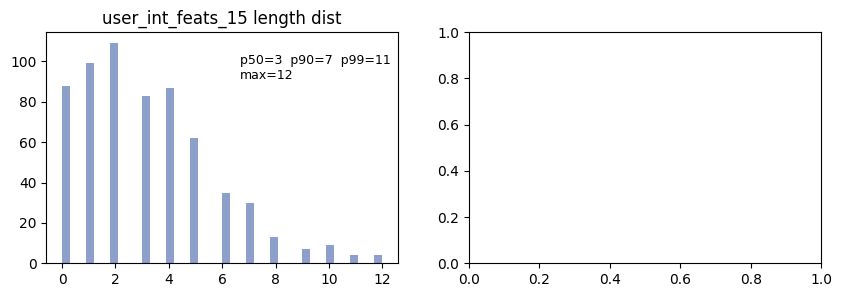

In [6]:
def _nonzero_len(x):
    if x is None:
        return 0
    arr = np.asarray(x)
    return int((arr != 0).sum())

def _iter_tokens(series, drop_pad=True):
    for v in series:
        if v is None:
            continue
        arr = np.asarray(v)
        if drop_pad:
            arr = arr[arr != 0]
        yield arr

def plot_seq_length(df, col, label_col, bins=None):
    lens = df[col].apply(_nonzero_len)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].hist(lens, bins=40, color='#8da0cb'); axes[0].set_title(f'{col} length dist')
    qs = lens.quantile([0.5, 0.9, 0.99]).to_dict()
    axes[0].text(0.55, 0.8, f'p50={qs[0.5]:.0f}  p90={qs[0.9]:.0f}  p99={qs[0.99]:.0f}\nmax={lens.max()}', transform=axes[0].transAxes, fontsize=9)
    # 길이 bin × CTR
    bins = bins or [0, 1, 5, 10, 20, 50, lens.max()+1]
    b = pd.cut(lens, bins=bins, right=False)
    ctr = df.assign(_b=b).groupby('_b')[label_col].agg(['count','mean']).dropna()
    axes[1].plot(range(len(ctr)), ctr['mean'], 'o-', color='#e41a1c')
    axes[1].set_xticks(range(len(ctr))); axes[1].set_xticklabels([str(i) for i in ctr.index], rotation=30)
    ax2 = axes[1].twinx(); ax2.bar(range(len(ctr)), ctr['count'], alpha=0.25, color='#8da0cb')
    axes[1].set_title(f'{col}: length-bin CTR (line) & count (bar)')
    plt.tight_layout(); plt.show()
    return lens

def plot_token_freq(df, col, topk=20):
    cnt = Counter()
    for arr in _iter_tokens(df[col]):
        cnt.update(arr.tolist())
    top = cnt.most_common(topk)
    if not top:
        print(f'{col}: no non-padding tokens'); return
    xs, ys = zip(*top)
    plt.figure(figsize=(10, 2.8)); plt.bar(range(len(xs)), ys, color='#66c2a5')
    plt.xticks(range(len(xs)), xs, rotation=60, fontsize=8); plt.title(f'{col}: top-{topk} token freq')
    plt.tight_layout(); plt.show()

def plot_bigram_heatmap(df, col, top_tokens=30):
    tok_cnt = Counter()
    for arr in _iter_tokens(df[col]):
        tok_cnt.update(arr.tolist())
    top = [t for t, _ in tok_cnt.most_common(top_tokens)]
    idx = {t: i for i, t in enumerate(top)}
    mat = np.zeros((len(top), len(top)), dtype=np.int64)
    for arr in _iter_tokens(df[col]):
        for a, b in zip(arr[:-1], arr[1:]):
            if a in idx and b in idx:
                mat[idx[a], idx[b]] += 1
    # row별 정규화 -> 전이 확률
    row_sum = mat.sum(axis=1, keepdims=True); row_sum[row_sum == 0] = 1
    prob = mat / row_sum
    plt.figure(figsize=(8, 6)); plt.imshow(prob, aspect='auto', cmap='viridis')
    plt.colorbar(label='P(next | current)')
    plt.xticks(range(len(top)), top, rotation=90, fontsize=7)
    plt.yticks(range(len(top)), top, fontsize=7)
    plt.title(f'{col}: bigram transition (top-{top_tokens} tokens)')
    plt.tight_layout(); plt.show()

if SEQ_COLS:
    for c in SEQ_COLS:
        print(f'\n=== sequence: {c} (max_len={FEATURES[c].get("max_len")}, vocab={FEATURES[c]["vocab_size"]}) ===')
        plot_seq_length(df, c, lbl)
        plot_token_freq(df, c, topk=TOPK)
        plot_bigram_heatmap(df, c, top_tokens=30)
else:
    print('no sequence features.')

## 6. 요약 메모

위 결과를 보고 데이터셋별 특성을 여기 직접 적으세요 (예: max_len 조정, 결측 처리, 다음 실험 아이디어 등).

- records:
- label prior (CTR):
- 가장 지배적인 카테고리 / sparsity:
- 시퀀스 길이 p50/p90/max:
- 주요 전이 패턴 / bias:
- TODO 아이디어:
